# ***Library***

In [375]:
import re
import nltk
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

# ***Download Data***

In [377]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [378]:
import kagglehub

path = kagglehub.dataset_download("team-ai/spam-text-message-classification")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/spam-text-message-classification


In [379]:
data = pd.read_csv(path + '/SPAM text message 20170820 - Data.csv')

In [380]:
data

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


# ***Describe Data***

In [381]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [382]:
data.duplicated().sum()

np.int64(415)

In [383]:
data.drop_duplicates(inplace=True)

In [384]:
data.describe()

,Category,Message
count,5157,5157
unique,2,5157
top,ham,Rofl. Its true to its name
freq,4516,1


In [385]:
import plotly.express as px

fig = px.pie(data, names='Category', title='Spam vs Ham Distribution')
fig.show()


In [386]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

In [387]:
def clean_text(text):
  text = text.lower()
  text = re.sub(r'[^\w\s]', '', text)
  text = re.sub(r'\d+','', text)
  tokens = word_tokenize(text)
  tokens = [word for word in tokens if word not in stop_words]
  tokens = [stemmer.stem(word) for word in tokens]
  text = ' '.join(tokens)
  return text

In [388]:
data['clean_text'] = data['Message'].apply(clean_text)

In [389]:
data

,Category,Message,clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,nd time tri contact u u pound prize claim easi...
5568,ham,Will ü b going to esplanade fr home?,ü b go esplanad fr home
5569,ham,"Pity, * was in mood for that. So...any other s...",piti mood soani suggest
5570,ham,The guy did some bitching but I acted like i'd...,guy bitch act like id interest buy someth els ...


In [390]:
data[data['Category']=='ham']['clean_text'].head(10)

,clean_text
0,go jurong point crazi avail bugi n great world...
1,ok lar joke wif u oni
3,u dun say earli hor u c alreadi say
4,nah dont think goe usf live around though
6,even brother like speak treat like aid patent
7,per request mell mell oru minnaminungint nurun...
10,im gon na home soon dont want talk stuff anymo...
13,ive search right word thank breather promis wo...
14,date sunday
16,oh kim watch


In [391]:
data[data['Category']=='spam']['clean_text'].head(10)

,clean_text
2,free entri wkli comp win fa cup final tkt st m...
5,freemsg hey darl week word back id like fun st...
8,winner valu network custom select receivea pri...
9,mobil month u r entitl updat latest colour mob...
11,six chanc win cash pound txt csh send cost pda...
12,urgent week free membership prize jackpot txt ...
15,xxxmobilemovieclub use credit click wap link n...
19,england v macedonia dont miss goalsteam news t...
34,thank subscript rington uk mobil charg month p...
42,rodger burn msg tri call repli sm free nokia m...


In [392]:
tfidf_vectorizer = TfidfVectorizer(max_features=3000)
x = tfidf_vectorizer.fit_transform(data['clean_text'])
x = pd.DataFrame(x.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

In [393]:
x

,aah,abi,abil,abiola,abj,abl,abstract,abt,abta,aburo,...,youwhen,yr,yummi,yun,yunni,yuo,yup,zed,zoe,üll
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5153,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5154,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5155,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [394]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y= le.fit_transform(data['Category'])

In [395]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(x, y)

In [396]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

In [397]:
RF = RandomForestClassifier()
RF.fit(X_train, y_train)
y_pred = RF.predict(X_test)

In [398]:
print(accuracy_score(y_test, y_pred))

0.9922523519645822


In [399]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       895
           1       0.99      0.99      0.99       912

    accuracy                           0.99      1807
   macro avg       0.99      0.99      0.99      1807
weighted avg       0.99      0.99      0.99      1807



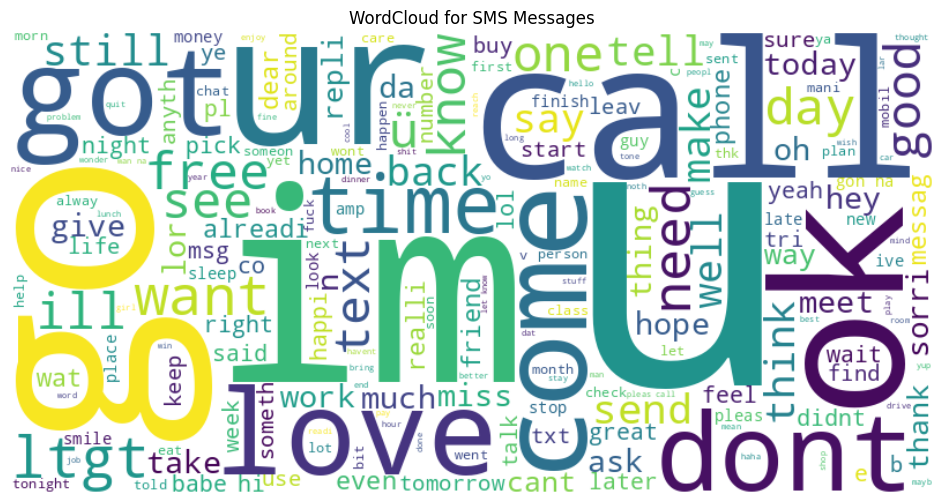

In [400]:
text = ' '.join(data['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud for SMS Messages')
plt.show()


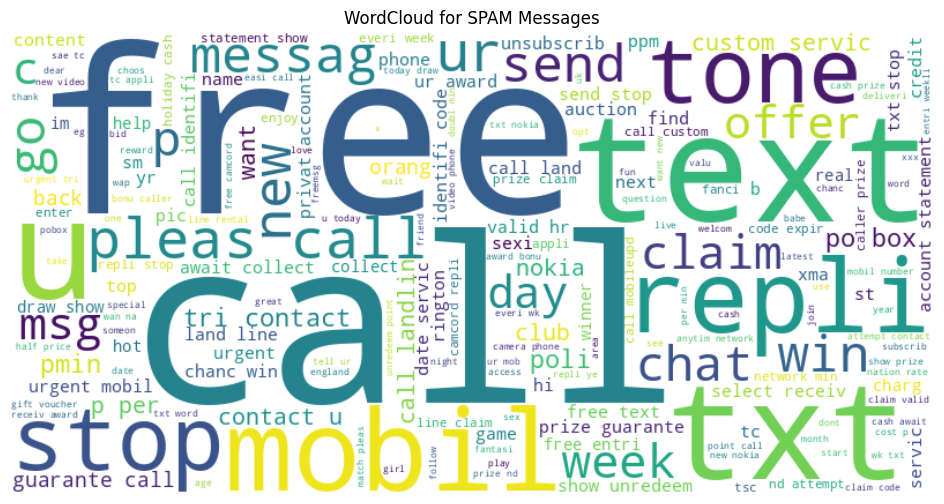

In [401]:
spam_text = ' '.join(data[data['Category'] == 'spam']['clean_text'])
wordcloud_spam = WordCloud(width=800, height=400, background_color='white').generate(spam_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud for SPAM Messages')
plt.show()


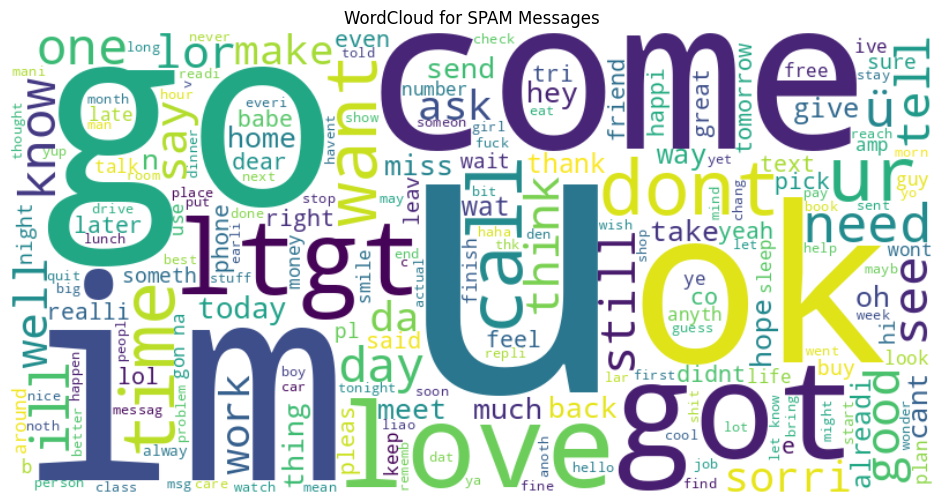

In [402]:
spam_text = ' '.join(data[data['Category'] == 'ham']['clean_text'])
wordcloud_spam = WordCloud(width=800, height=400, background_color='white').generate(spam_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud for SPAM Messages')
plt.show()
